In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('cardekho.csv')

In [3]:
data.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


## Важная находка касательно оценки плотности пост-интервенционных данных


$\mathbb{P}(Y=y|do(A=a))=\int_{x \in \mathbb{X}} \mathbb{P}(Y=y|A=a,X=x) \mathbb{P}(X=x) dx=\mathbb{E}_{x} \mathbb{P}(Y=y|A=a,X=x)$

Взято из статьи **Normalizing Flows for Interventional Density Estimation**(https://arxiv.org/pdf/2209.06203)

Здесь под $А$ имеем в виду переменную, куда делаем интервенцию, под $X$ **ВСЕ ОСТАЛЬНЫЕ ПЕРЕМЕННЫЕ DAG-a** и под $Y$ - переменную, плотность которой после интервенции хотим оценить.

Топ-модель: Maruti Swift Dzire VDI (129 шт.)
K = 29 классов (годов): 1983..2020


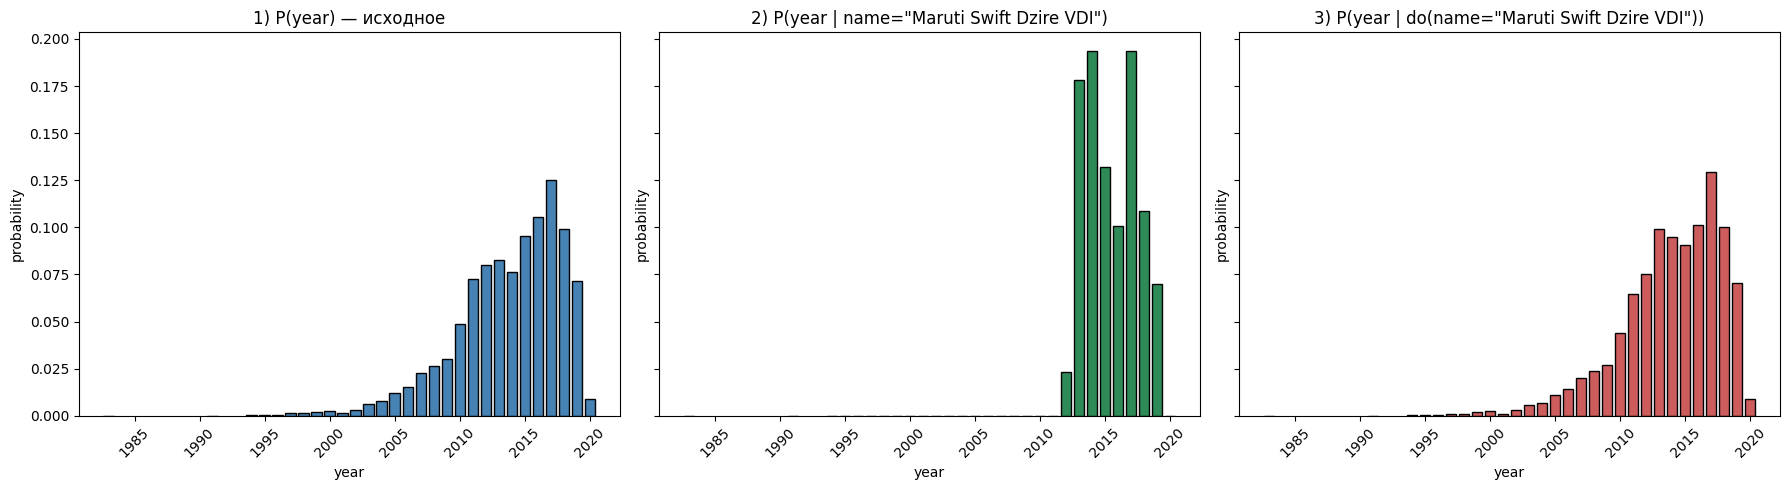

1) P(year)                     mean=2013.80 std=4.04
2) P(year|name=a)              mean=2015.47 std=1.97
3) P(year|do(name=a))          mean=2013.92 std=3.93

TV(P(Y|A=a), P(Y|do(A=a))) = 0.2922


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

data = pd.read_csv('cardekho.csv')

A_col, Y_col = 'name', 'year'

# ---------- 1) самая частая машина ----------
top_name = data['name'].value_counts().idxmax()
print(f"Топ-модель: {top_name} ({data['name'].value_counts().max()} шт.)")

# ---------- 2) признаки ----------
X_cols = [c for c in data.columns if c not in (A_col, Y_col)]
df = data.copy()
df_enc = pd.get_dummies(df[X_cols + [A_col]], drop_first=False)

# ---------- 3) классы-годы ----------
classes = np.sort(df[Y_col].unique())
K = len(classes)
cls_to_idx = {c: i for i, c in enumerate(classes)}
y_idx = df[Y_col].map(cls_to_idx).values
print(f"K = {K} классов (годов): {classes.min()}..{classes.max()}")

# ---------- 4) обучаем P(Y | A, X) ----------
clf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=3,
    random_state=0, n_jobs=-1
)
clf.fit(df_enc, y_idx)

# ---------- 5) P(Y | A=a) — условное, просто фильтр ----------
mask_a = df[A_col] == top_name
Y_cond = df.loc[mask_a, Y_col].values

# ---------- 6) P(Y | do(A=a)) — по формуле, без семплирования ----------
# для каждой строки X=x_i подставляем A=a и берём условное распределение,
# затем усредняем по всем i с весом 1/n:
#   P(Y=y | do(A=a)) = (1/n) * sum_i P(Y=y | A=a, X=x_i)
df_int = df.copy()
df_int[A_col] = top_name
df_int_enc = pd.get_dummies(df_int[X_cols + [A_col]], drop_first=False)
df_int_enc = df_int_enc.reindex(columns=df_enc.columns, fill_value=0)

proba = clf.predict_proba(df_int_enc)     # (n, K)
p_do = proba.mean(axis=0)                 # (K,) — достоверная оценка P(Y | do(A=a))

# ---------- 7) три распределения ----------
# 1) исходное — эмпирическая частота по всей выборке
counts_all = df[Y_col].value_counts().reindex(classes, fill_value=0).values
p_all = counts_all / counts_all.sum()

# 2) условное P(Y | A=a) — эмпирическая частота среди строк с name=a
counts_cond = df.loc[mask_a, Y_col].value_counts().reindex(classes, fill_value=0).values
p_cond = counts_cond / counts_cond.sum()

# 3) post-do — p_do (уже нормировано)

# ---------- 8) графики ----------
fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

ax[0].bar(classes, p_all, color='steelblue', edgecolor='black')
ax[0].set_title('1) P(year) — исходное')

ax[1].bar(classes, p_cond, color='seagreen', edgecolor='black')
ax[1].set_title(f'2) P(year | name="{top_name}")')

ax[2].bar(classes, p_do, color='indianred', edgecolor='black')
ax[2].set_title(f'3) P(year | do(name="{top_name}"))')

for a in ax:
    a.set_xlabel('year'); a.set_ylabel('probability')
    a.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

# ---------- 9) числовые характеристики ----------
def stats(p, classes):
    m = np.sum(p * classes)
    v = np.sum(p * (classes - m) ** 2)
    return m, np.sqrt(v)

for label, p in [("1) P(year)", p_all),
                 (f"2) P(year|name=a)", p_cond),
                 (f"3) P(year|do(name=a))", p_do)]:
    m, s = stats(p, classes)
    print(f"{label:30s} mean=%.2f std=%.2f" % (m, s))

# ---------- 10) количественное сравнение 2 vs 3 ----------
tv = 0.5 * np.abs(p_cond - p_do).sum()      # total variation distance
print(f"\nTV(P(Y|A=a), P(Y|do(A=a))) = {tv:.4f}")

Топ-модель (для справки): Maruti Swift Dzire VDI (129 шт.)
K = 2058 классов (моделей)
Год для интервенции A=a: 2017 (1018 шт.)


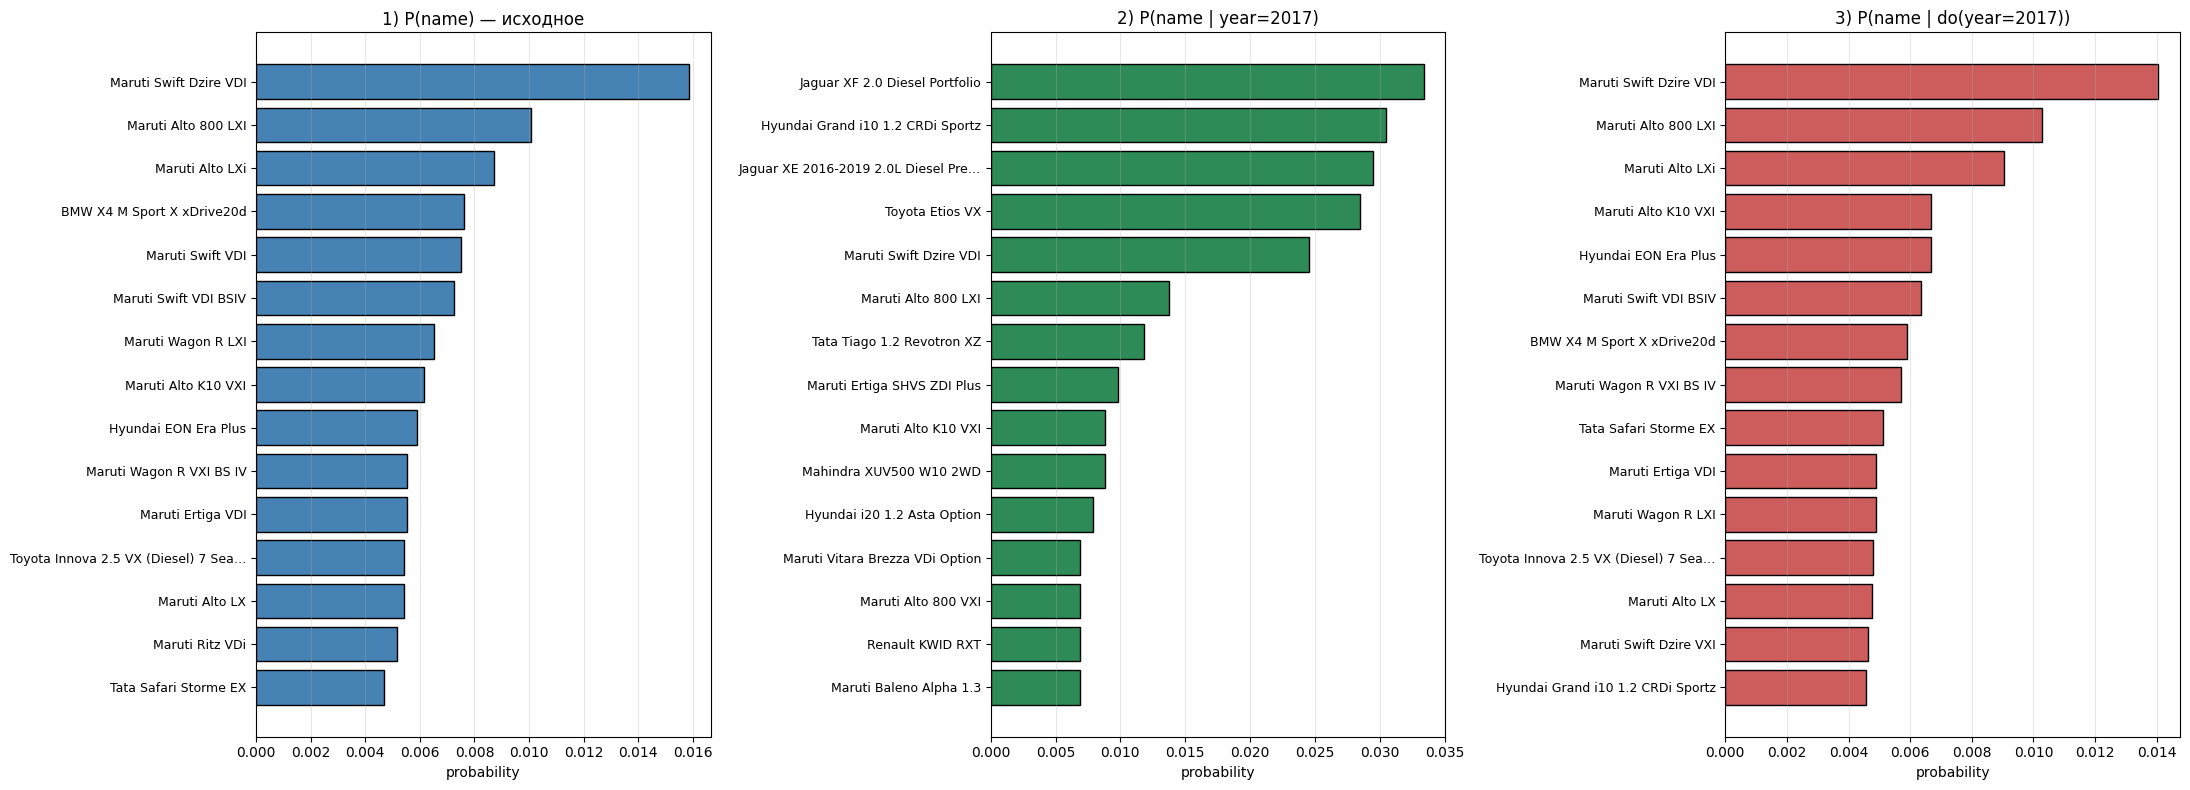


1) P(name)
  top-1 модель: Maruti Swift Dzire VDI  (p=0.0159)
  top-5: ['Maruti Swift Dzire VDI', 'Maruti Alto 800 LXI', 'Maruti Alto LXi', 'BMW X4 M Sport X xDrive20d', 'Maruti Swift VDI']
  entropy = 6.947
  eff. число моделей = exp(entropy) = 1039.5

2) P(name | year=2017)
  top-1 модель: Jaguar XF 2.0 Diesel Portfolio  (p=0.0334)
  top-5: ['Jaguar XF 2.0 Diesel Portfolio', 'Hyundai Grand i10 1.2 CRDi Sportz', 'Jaguar XE 2016-2019 2.0L Diesel Prestige', 'Toyota Etios VX', 'Maruti Swift Dzire VDI']
  entropy = 5.588
  eff. число моделей = exp(entropy) = 267.1

3) P(name | do(year=2017))
  top-1 модель: Maruti Swift Dzire VDI  (p=0.0141)
  top-5: ['Maruti Swift Dzire VDI', 'Maruti Alto 800 LXI', 'Maruti Alto LXi', 'Maruti Alto K10 VXI', 'Hyundai EON Era Plus']
  entropy = 6.949
  eff. число моделей = exp(entropy) = 1041.9

TV(P(name|year=a), P(name|do(year=a))) = 0.5989


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

data = pd.read_csv('cardekho.csv')

A_col, Y_col = 'year', 'name'   # <-- поменяли местами

# ---------- 1) самая частая машина (для справки) ----------
top_name = data['name'].value_counts().idxmax()
print(f"Топ-модель (для справки): {top_name} "
      f"({data['name'].value_counts().max()} шт.)")

# ---------- 2) признаки ----------
# A — это year (числовой, one-hot не нужен, оставим как есть в df_enc)
# X — всё остальное кроме name и year
X_cols = [c for c in data.columns if c not in (A_col, Y_col)]
df = data.copy()

# one-hot для X и для A=year
df_enc = pd.get_dummies(df[X_cols + [A_col]], drop_first=False)

# ---------- 3) классы — теперь это name ----------
classes = np.sort(df[Y_col].unique())
K = len(classes)
cls_to_idx = {c: i for i, c in enumerate(classes)}
y_idx = df[Y_col].map(cls_to_idx).values
print(f"K = {K} классов (моделей)")

# ---------- 4) обучаем P(Y=name | A=year, X) ----------
clf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    random_state=0, n_jobs=-1
)
clf.fit(df_enc, y_idx)

# ---------- 5) выбираем год для интервенции ----------
# логично взять самый частый год — аналог «топ-модели» из прошлой задачи
top_year = int(df[A_col].value_counts().idxmax())
print(f"Год для интервенции A=a: {top_year} "
      f"({df[A_col].value_counts().max()} шт.)")

# ---------- 6) P(Y | A=a) — условное, фильтр по year=a ----------
mask_a = df[A_col] == top_year
Y_cond = df.loc[mask_a, Y_col].values

# ---------- 7) P(Y | do(A=a)) — формула, без семплирования ----------
df_int = df.copy()
df_int[A_col] = top_year
df_int_enc = pd.get_dummies(df_int[X_cols + [A_col]], drop_first=False)
df_int_enc = df_int_enc.reindex(columns=df_enc.columns, fill_value=0)

proba = clf.predict_proba(df_int_enc)     # (n, K)
p_do = proba.mean(axis=0)                 # (K,) — P(name | do(year=a))

# ---------- 8) три распределения по моделям ----------
counts_all = df[Y_col].value_counts().reindex(classes, fill_value=0).values
p_all = counts_all / counts_all.sum()

counts_cond = df.loc[mask_a, Y_col].value_counts().reindex(classes, fill_value=0).values
p_cond = counts_cond / counts_cond.sum()

# p_do уже нормировано

# ---------- 9) графики: Top-N для каждого распределения ----------
TOP_N = 15

def top_n(p, classes, n=TOP_N):
    idx = np.argsort(p)[::-1][:n]
    labels = [classes[i][:35] + ('…' if len(classes[i]) > 35 else '')
              for i in idx]
    return labels, p[idx]

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

distributions = [
    (p_all,  'steelblue', '1) P(name) — исходное'),
    (p_cond, 'seagreen',  f'2) P(name | year={top_year})'),
    (p_do,   'indianred', f'3) P(name | do(year={top_year}))'),
]

for ax, (p, color, title) in zip(axes, distributions):
    labels, vals = top_n(p, classes)
    # горизонтальные бары: сверху — самый вероятный
    y_pos = np.arange(len(labels))[::-1]
    ax.barh(y_pos, vals, color=color, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('probability')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- 10) числовые характеристики ----------
# mean/std по годам-классам тут не имеют смысла (классы — строки),
# поэтому смотрим на concentration: max prob, entropy, top-1 модель
from scipy.stats import entropy

def summarize(p, classes, label):
    idx_sorted = np.argsort(p)[::-1]
    top1 = classes[idx_sorted[0]]
    top5 = [classes[i] for i in idx_sorted[:5]]
    ent = entropy(p + 1e-12)          # нат. единицы
    print(f"\n{label}")
    print(f"  top-1 модель: {top1}  (p={p[idx_sorted[0]]:.4f})")
    print(f"  top-5: {top5}")
    print(f"  entropy = {ent:.3f}")
    print(f"  eff. число моделей = exp(entropy) = {np.exp(ent):.1f}")

summarize(p_all,  classes, '1) P(name)')
summarize(p_cond, classes, f'2) P(name | year={top_year})')
summarize(p_do,   classes, f'3) P(name | do(year={top_year}))')

# ---------- 11) TV между 2 и 3 ----------
tv = 0.5 * np.abs(p_cond - p_do).sum()
print(f"\nTV(P(name|year=a), P(name|do(year=a))) = {tv:.4f}")